<a href="https://colab.research.google.com/github/rocio-mr/PCA-and-anomaly-detection/blob/main/reduccion_dimensionalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PARTE I:
Use el dataset “Olivetti Faces Dataset” de scikit-learn para crear un Sistema de reconocimiento de rostros basado en Eigenfaces. No debe usar algoritmos de redes neuronales. [Hint. PCA]

In [ ]:
#Cargamos el dataset e importamos las librerias necesarias
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

faces = fetch_olivetti_faces()

In [ ]:
#Dividir en X e y
X = faces.data
y = faces.target
#Guardar las imágenes del dataset
images = faces.images

In [ ]:
#Número de imágenes
images.shape[0]

400

In [ ]:
#Tamaño de las imágenes

images.shape[1:]

(64, 64)

In [ ]:
#Número de personas
len(np.unique(y))

40

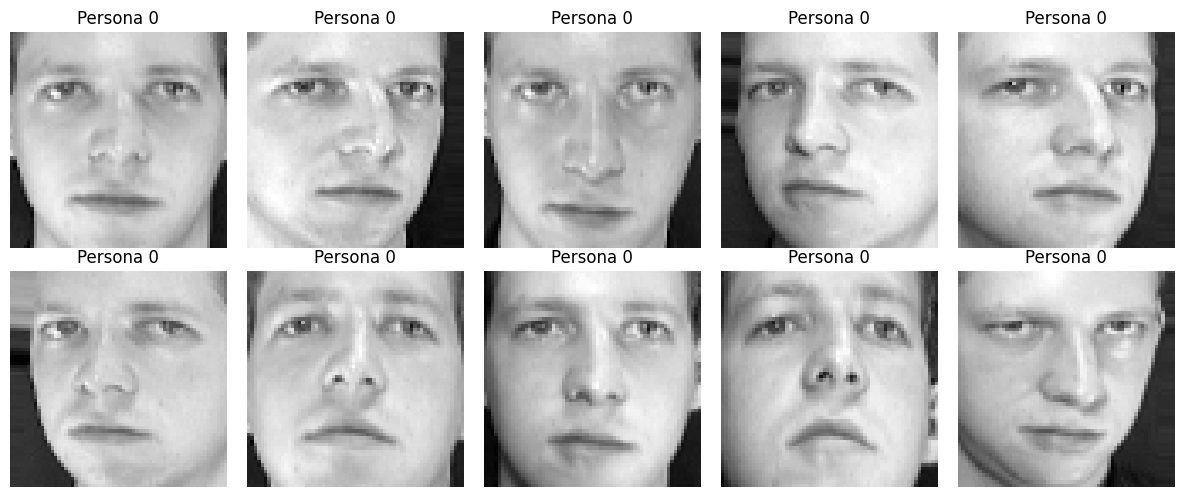

In [ ]:
#Visualizar algunas imágenes que conforman el dataset

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
  ax.imshow(images[i], cmap='gray')
  ax.set_title(f"Persona {y[i]}")
  ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Dividimos en train y test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Train
X_train.shape

(320, 4096)

In [ ]:
#Test
y_train.shape

(320,)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#Comparación entre diferentes cantidades de eigenfaces
componentes = [10, 20, 30, 40, 50, 75, 100, 150, 200, 300]

resultados = []

for n in componentes:

    #Aplicación de PCA

    pca = PCA(n_components=n, whiten=True, random_state=42)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    #Aplicación del clasificador
    knn_faces = KNeighborsClassifier(n_neighbors=3)
    knn_faces.fit(X_train_pca, y_train)

    #Predicción
    y_pred = knn_faces.predict(X_test_pca)

    #Evaluación del modelo
    accuracy = accuracy_score(y_test, y_pred)

    resultados.append({
        "Eigenfaces": n,
        "Accuracy": accuracy
    })


In [ ]:
import pandas as pd

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

   Eigenfaces  Accuracy
0          10    0.8000
1          20    0.9000
2          30    0.9125
3          40    0.9125
4          50    0.9000
5          75    0.8625
6         100    0.8125
7         150    0.7375
8         200    0.6125
9         300    0.4750


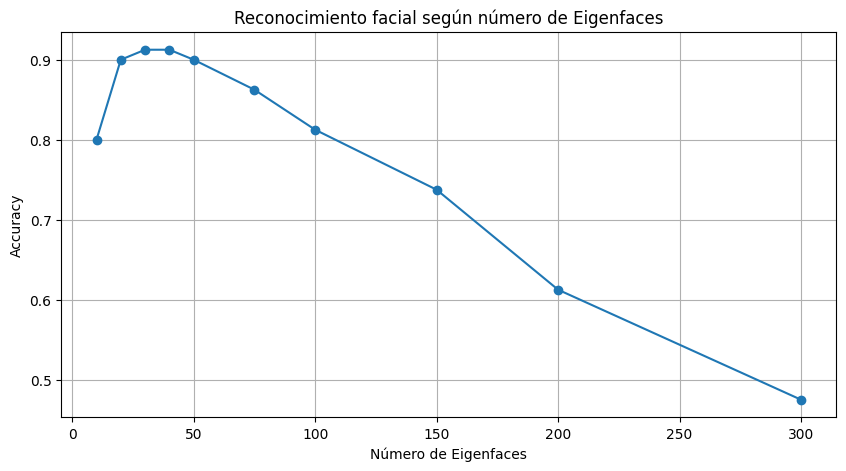

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_resultados["Eigenfaces"],
    df_resultados["Accuracy"],
    marker="o"
)

plt.xlabel("Número de Eigenfaces")
plt.ylabel("Accuracy")
plt.title("Reconocimiento facial según número de Eigenfaces")
plt.grid()

plt.show()

In [ ]:
#Por lo tanto, se usarán 50 Eigenfaces para reconstruir una imagen

pca = PCA(n_components=50, whiten=True, random_state=42)

X_train_pca = pca.fit_transform(X_train)

In [ ]:
X_test_reconstruido = pca.inverse_transform(
    pca.transform(X_test)
)

In [ ]:
indice = 0

rostro_original = X_test[indice].reshape(64, 64)
rostro_reconstruido = X_test_reconstruido[indice].reshape(64, 64)

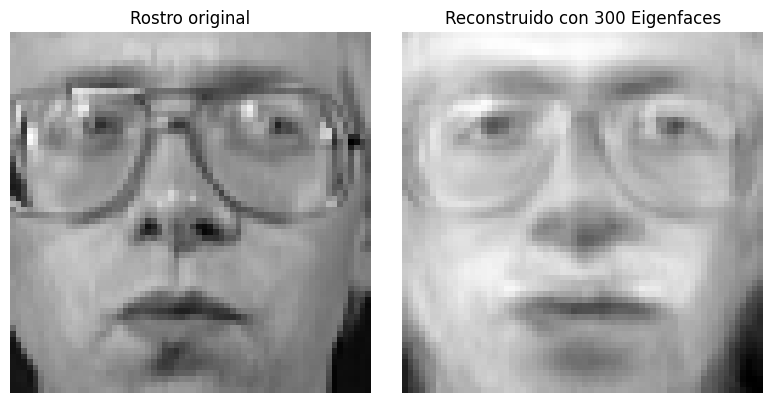

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(rostro_original, cmap="gray")
axes[0].set_title("Rostro original")
axes[0].axis("off")

axes[1].imshow(rostro_reconstruido, cmap="gray")
axes[1].set_title("Reconstruido con 300 Eigenfaces")
axes[1].axis("off")

plt.tight_layout()
plt.show()

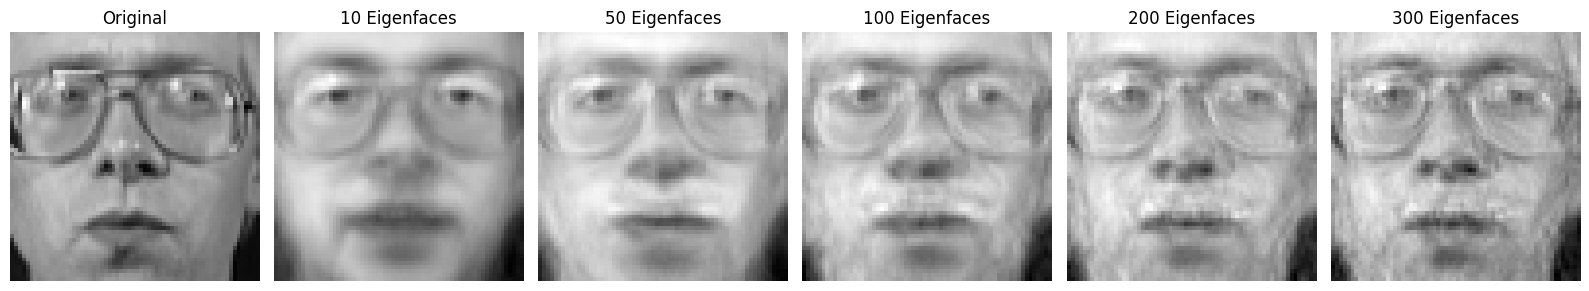

In [ ]:
#Ahora visualmente se muestra cada imagen resconstruida con diferentes números de Eigenfaces

componentes = [10, 50, 100, 200, 300]

indice = 0

fig, axes = plt.subplots(
    1,
    len(componentes) + 1,
    figsize=(16, 4)
)

# Original
axes[0].imshow(
    X_test[indice].reshape(64, 64),
    cmap="gray"
)

axes[0].set_title("Original")
axes[0].axis("off")

# Diferentes Eigenfaces
for i, n in enumerate(componentes):

    pca_temp = PCA(n_components=n)

    X_train_temp = pca_temp.fit_transform(X_train)

    rostro_pca = pca_temp.transform(
        X_test[indice].reshape(1, -1)
    )

    rostro_reconstruido = pca_temp.inverse_transform(
        rostro_pca
    )

    axes[i+1].imshow(
        rostro_reconstruido.reshape(64, 64),
        cmap="gray"
    )

    axes[i+1].set_title(f"{n} Eigenfaces")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Usar los 50 Eigenfaces para el sistema de reconocimiento
pca = PCA(n_components=50, whiten=True)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
#Mostrar el reconocimiento de una imagen seleccionando una imagen del conjunto de prueba

indice = 10

imagen = X_test[indice]
etiqueta_real = y_test[indice]

In [ ]:
imagen_pca = pca.transform(
    imagen.reshape(1, -1)
)

In [ ]:
prediccion = knn.predict(imagen_pca)[0]

In [ ]:
print("Persona real:", etiqueta_real)
print("Persona reconocida:", prediccion)

Persona real: 25
Persona reconocida: 25


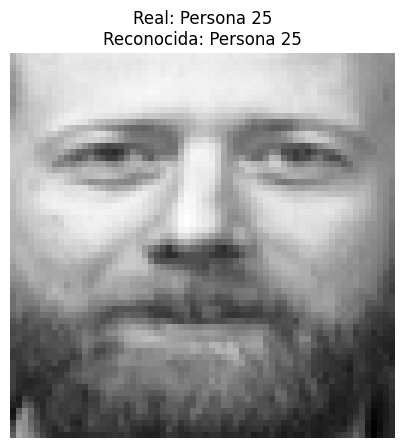

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(
    imagen.reshape(64, 64),
    cmap="gray"
)

plt.title(
    f"Real: Persona {etiqueta_real}\n"
    f"Reconocida: Persona {prediccion}"
)

plt.axis("off")

plt.show()

#PARTE II:

Supongan que forman parte del grupo de Machine Learning en un importante periódico en línea. Les han asignado la tarea de recomendar artículos similares al artículo que está leyendo actualmente un cliente. Es decir, dado un artículo, se debe encontrar artículos que tengan temas similares. Resuelvan el problema usando NMF y similitud de coseno o alguno similar.

In [ ]:
#Importamos el dataset solo la parte del train

from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

In [ ]:
documents = newsgroups.data
labels = newsgroups.target
categories = newsgroups.target_names

In [ ]:
#Número de articulos
len(documents)

11314

In [ ]:
#Número de categorías
len(categories)

20

In [ ]:
#Vemos las categorías

for i, category in enumerate(categories):
  print(i, category)

0 alt.atheism
1 comp.graphics
2 comp.os.ms-windows.misc
3 comp.sys.ibm.pc.hardware
4 comp.sys.mac.hardware
5 comp.windows.x
6 misc.forsale
7 rec.autos
8 rec.motorcycles
9 rec.sport.baseball
10 rec.sport.hockey
11 sci.crypt
12 sci.electronics
13 sci.med
14 sci.space
15 soc.religion.christian
16 talk.politics.guns
17 talk.politics.mideast
18 talk.politics.misc
19 talk.religion.misc


In [ ]:
#Convertir los articulos en TF-IDF, es decir, de texto a números

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(documents)

#Imprimir las dimensiones
print("Dimensiones: ", X_tfidf.shape)

Dimensiones:  (11314, 5000)


In [ ]:
#Aplicar el NFM

from sklearn.decomposition import NMF

n_topics = 20

nmf = NMF(
    n_components=n_topics,
    random_state=42,
    init='nndsvda',
    max_iter=400
)

W = nmf.fit_transform(X_tfidf)
H = nmf.components_

print("Matriz W:", W.shape)
print("Matriz H:", H.shape)

Matriz W: (11314, 20)
Matriz H: (20, 5000)


In [ ]:
#Observar las palabras principales de cada componente de NFM

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(H):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:][::-1]
    ]

    print(f"Tema {topic_idx}:")
    print(", ".join(top_words))
    print()

Tema 0:
people, right, gun, government, law, make, did, guns, state, point

Tema 1:
thanks, mail, advance, hi, looking, info, help, information, appreciated, address

Tema 2:
god, jesus, bible, faith, believe, christ, christian, christians, church, life

Tema 3:
geb, dsl, chastity, n3jxp, cadre, pitt, shameful, intellect, skepticism, surrender

Tema 4:
key, chip, encryption, clipper, keys, escrow, government, algorithm, phone, nsa

Tema 5:
drive, scsi, drives, disk, hard, ide, controller, floppy, cd, mac

Tema 6:
00, sale, new, shipping, offer, price, 10, condition, 50, asking

Tema 7:
windows, file, dos, files, ms, program, version, ftp, running, pc

Tema 8:
game, team, year, games, players, season, play, hockey, win, league

Tema 9:
israel, israeli, jews, arab, jewish, arabs, peace, lebanon, lebanese, israelis

Tema 10:
card, video, monitor, bus, drivers, vga, cards, driver, color, ram

Tema 11:
car, bike, cars, good, engine, miles, dealer, speed, oil, tires

Tema 12:
space, nasa, sh

In [ ]:
indice_articulo = 100
W[indice_articulo]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.87879958e-05,
       0.00000000e+00, 0.00000000e+00, 3.60995825e-02, 1.32413804e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 8.28682666e-03, 0.00000000e+00,
       0.00000000e+00, 5.03090983e-03, 0.00000000e+00, 0.00000000e+00])

In [ ]:
#Implementación del recomendador utilizando la similitud del coseno

from sklearn.metrics.pairwise import cosine_similarity

similitudes = cosine_similarity(
    W[indice_articulo].reshape(1, -1),
    W
)[0]

In [ ]:
indices_similares = similitudes.argsort()[::-1]

In [ ]:
top_n = 5

recomendaciones = indices_similares[1:top_n + 1]

In [ ]:
print("ARTÍCULO ACTUAL")
print("-" * 80)
print(documents[indice_articulo][:500])

print("\nARTÍCULOS RECOMENDADOS")
print("=" * 80)

for i, indice in enumerate(recomendaciones, start=1):
    print(f"\n{i}. Artículo {indice}")
    print(f"Similitud: {similitudes[indice]:.4f}")
    print(documents[indice][:500])

ARTÍCULO ACTUAL
--------------------------------------------------------------------------------
1.  Software publishing SuperBase 4 windows v.1.3           --->$80

2.  OCR System ReadRight v.3.1 for Windows                  --->$65

3.  OCR System ReadRight  v.2.01 for DOS                    --->$65

4.  Unregistered Zortech 32 bit C++ Compiler v.3.1          --->$ 250
     with Multiscope windows Debugger,
     WhiteWater Resource Toolkit, Library Source Code

5.  Glockenspiel/ImageSoft Commonview 2 Windows
     Applications Framework for Borland C++                 --->$70

6.  Spontane

ARTÍCULOS RECOMENDADOS

1. Artículo 7658
Similitud: 0.9947
To clarify:  

VC++ *is* considered an upgrade for C7.  There will be no product
called C 8.0 (although the command-line compiler of VC++ lists its
version as 8.00).  C7 is not a "DOS"-only product -- it is a C/C++
compiler capable of producing executables for DOS or Windows, as is
VC++ (Pro. Ed.).  The (significant) difference is that VC++

In [ ]:
print("ARTÍCULO ACTUAL")
print("Categoría:", categories[labels[indice_articulo]])
print(documents[indice_articulo][:300])

print("\nRECOMENDACIONES")
print("=" * 70)

for i, indice in enumerate(recomendaciones, start=1):

    print(f"\n{i}. Artículo {indice}")
    print("Categoría:", categories[labels[indice]])
    print("Similitud:", round(similitudes[indice], 4))
    print(documents[indice][:300])

ARTÍCULO ACTUAL
Categoría: misc.forsale
1.  Software publishing SuperBase 4 windows v.1.3           --->$80

2.  OCR System ReadRight v.3.1 for Windows                  --->$65

3.  OCR System ReadRight  v.2.01 for DOS                    --->$65

4.  Unregistered Zortech 32 bit C++ Compiler v.3.1          --->$ 250
     with Multiscope wi

RECOMENDACIONES

1. Artículo 7658
Categoría: comp.os.ms-windows.misc
Similitud: 0.9947
To clarify:  

VC++ *is* considered an upgrade for C7.  There will be no product
called C 8.0 (although the command-line compiler of VC++ lists its
version as 8.00).  C7 is not a "DOS"-only product -- it is a C/C++
compiler capable of producing executables for DOS or Windows, as is
VC++ (Pro. Ed.). 

2. Artículo 5897
Categoría: comp.os.ms-windows.misc
Similitud: 0.9909
Chicago from what I have read is projected to run in 4M on 386 and higher.
It is definitely aimed at the desktop. 
It  is rumored to offer preemptive multitasking,
multithreading but will not offer m

In [ ]:
#Evaluación del recomendador

correctas = 0
total = 0

for indice_articulo in range(100):

    similitudes = cosine_similarity(
        W[indice_articulo].reshape(1, -1),
        W
    )[0]

    indices = similitudes.argsort()[::-1][1:6]

    categoria_original = labels[indice_articulo]

    for indice in indices:
        if labels[indice] == categoria_original:
            correctas += 1

        total += 1

precision_recomendacion = correctas / total

print(
    f"Precisión temática: "
    f"{precision_recomendacion:.2%}"
)

Precisión temática: 42.00%


#PARTE III:
Entrene un modelo ensemble para detectar anomalías en series temporales.

In [ ]:
#Cargar el dataset

import pandas as pd

df = pd.read_csv("cpu_utilization_asg_misconfiguration.csv")

In [ ]:
df.head()

,timestamp,value
0,2014-05-14 01:14:00,85.835
1,2014-05-14 01:19:00,88.167
2,2014-05-14 01:24:00,44.595
3,2014-05-14 01:29:00,56.282
4,2014-05-14 01:34:00,36.534


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18050 entries, 0 to 18049
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  18050 non-null  object 
 1   value      18050 non-null  float64
dtypes: float64(1), object(1)
memory usage: 282.2+ KB


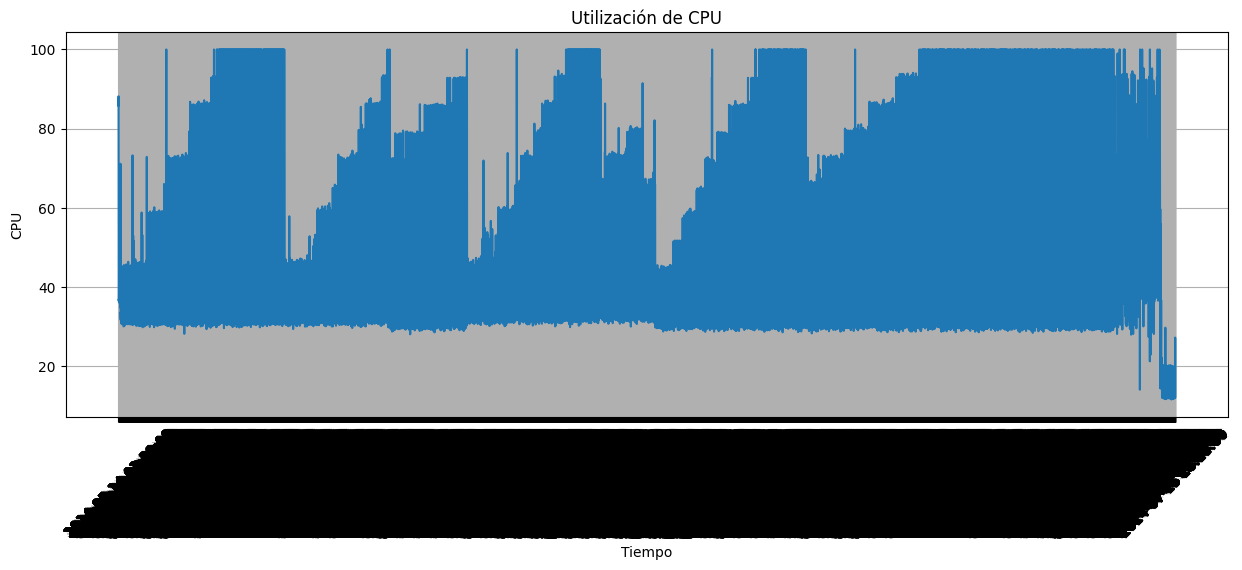

In [ ]:
#Visualizar la serie

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df["timestamp"],
    df["value"]
)

plt.title("Utilización de CPU")
plt.xlabel("Tiempo")
plt.ylabel("CPU")

plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
#Crear características

df["value_lag1"] = df["value"].shift(1)

df["value_lag2"] = df["value"].shift(2)

df["rolling_mean"] = (
    df["value"]
    .rolling(window=10)
    .mean()
)

df["rolling_std"] = (
    df["value"]
    .rolling(window=10)
    .std()
)

df["difference"] = (
    df["value"] - df["value_lag1"]
)

df = df.dropna().reset_index(drop=True)

In [ ]:
X = df[
    [
        "value",
        "value_lag1",
        "value_lag2",
        "rolling_mean",
        "rolling_std",
        "difference"
    ]
]

In [ ]:
#Implementación del ensemble

#Isolation Forest

from sklearn.ensemble import IsolationForest

modelo_if = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

pred_if = modelo_if.fit_predict(X)

df["IF"] = (pred_if == -1).astype(int)

In [ ]:
#LOF

from sklearn.neighbors import LocalOutlierFactor

modelo_lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

pred_lof = modelo_lof.fit_predict(X)

df["LOF"] = (pred_lof == -1).astype(int)

In [ ]:
#One Class SVM

from sklearn.svm import OneClassSVM

modelo_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.02
)

modelo_svm.fit(X)

pred_svm = modelo_svm.predict(X)

df["SVM"] = (pred_svm == -1).astype(int)

In [ ]:
#Ensemble

df["votos"] = (
    df["IF"] +
    df["LOF"] +
    df["SVM"]
)

df["anomalia"] = (
    df["votos"] >= 2
).astype(int)

In [ ]:
#Mostrar las anomalías

anomalias = df[df["anomalia"] == 1]

print("Número de anomalías detectadas:")
print(len(anomalias))

display(
    anomalias[
        [
            "timestamp",
            "value",
            "IF",
            "LOF",
            "SVM",
            "votos"
        ]
    ].head(20)
)

Número de anomalías detectadas:
192


,timestamp,value,IF,LOF,SVM,votos
474,2014-05-15 17:29:00,72.8350,0,1,1,2
808,2014-05-16 21:19:00,100.0000,1,0,1,2
809,2014-05-16 21:24:00,45.3840,1,1,0,2
2822,2014-05-23 21:09:00,100.0000,1,0,1,2
2823,2014-05-23 21:14:00,85.8870,1,0,1,2
2824,2014-05-23 21:19:00,79.4755,1,0,1,2
2909,2014-05-24 04:24:00,31.2220,0,1,1,2
4584,2014-05-29 23:59:00,71.8740,0,1,1,2
4586,2014-05-30 00:09:00,100.0000,1,0,1,2
4587,2014-05-30 00:14:00,82.7780,1,0,1,2


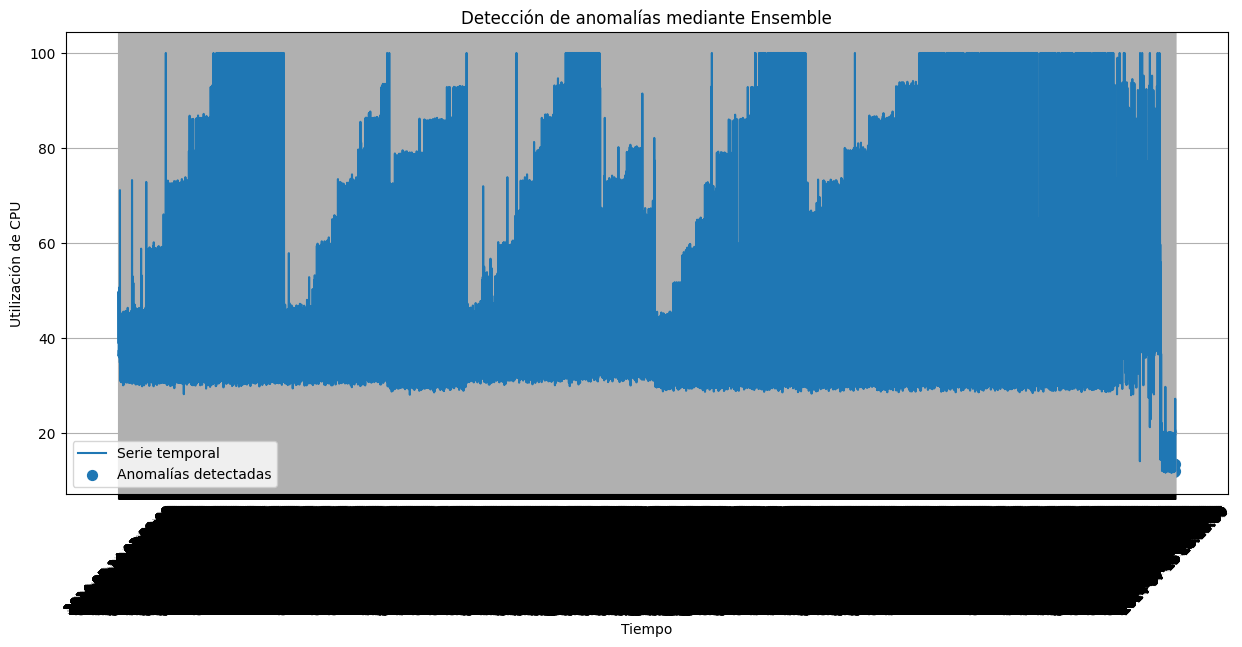

In [ ]:
#Visualizar gráfico final

plt.figure(figsize=(15, 6))

plt.plot(
    df["timestamp"],
    df["value"],
    label="Serie temporal"
)

plt.scatter(
    anomalias["timestamp"],
    anomalias["value"],
    label="Anomalías detectadas",
    s=50
)

plt.title(
    "Detección de anomalías mediante Ensemble"
)

plt.xlabel("Tiempo")
plt.ylabel("Utilización de CPU")

plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()